In [6]:
import numpy as np
import os
import globals as gl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import seaborn as sns
from Plot import make_yref, set_spines_and_ticks_width, save_figure_incremental
from Plot import plot_force_aligned, annotate_finger_labels,auto_margin
plt.style.use('default')

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/force_response.svg


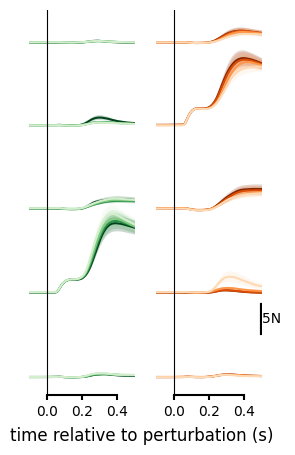

In [7]:
# === Load data ===
experiment = 'smp2'
npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']

fig, axs = plt.subplots(1, 2, figsize=(3, 5), sharey=True, sharex=True)

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for f, finger in enumerate(descr.finger.unique()):
    for stimFinger in descr.stimFinger.unique():
        for cue in descr.cue.unique():
            force_tmp = force[(descr.cue == cue) & (descr.stimFinger == stimFinger) & (descr.finger == finger)]

            if stimFinger == 'index':
                ax=axs[0]
            else:
                ax=axs[1]

            y = force_tmp.mean(axis=0) + f * 15
            yerr = force_tmp.std(axis=0) / np.sqrt(force_tmp.shape[0])

            if ~np.isnan(y).any():
                ax.plot(tAx, y, color=gl.colour_mapping[f'{cue},{stimFinger}'])
                ax.fill_between(tAx, y - yerr, y + yerr, color=gl.colour_mapping[f'{cue},{stimFinger}'], lw=0, alpha=.2)
# # === Initialize figure ===
# fig, axs = plt.subplots(ncols=3, figsize=(8, 5))
# vsep_go, vsep_nogo = 15, 1.5
#
# colors_go = list(gl.colour_mapping.values())[5:10]
# colors_nogo = list(gl.colour_mapping.values())[0:5]
#
# # === Plotting ===
# plot_force_aligned(force, descr, 'go', vsep_go, axs)
# plot_force_aligned(force, descr,'nogo', vsep_nogo, axs)
# annotate_finger_labels(force, descr, axs[0], vsep_nogo)
#
# # === Titles and intervals ===
# for sf, stimF in enumerate(descr.stimFinger.unique()):
#     axs[sf].set_title(f'{stimF} perturbation' if stimF != 'nogo' else 'nogo trials')
#
# axs[0].axvspan(-1.5, 0, color='grey', alpha=.3, lw=0)
# axs[1].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
# axs[2].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
#
axs[0].set_xlim([-.1, .5])
axs[1].set_xlim([-.1, .5])
# axs[2].set_xlim([-.1, .5])
#
# axs[0].set_ylim([-.21, 6.90])
# axs[1].set_ylim(auto_margin(axs[1].lines))
# axs[2].set_ylim(auto_margin(axs[2].lines))
#
# axs[0].set_xticks([-1.5, 0, .4])
axs[0].set_xticks([0, .2, .4])
axs[1].set_xticks([0, .2, .4])
#
make_yref(axs[1], reference_length=5, pos='right')
# make_yref(axs[0], reference_length=.5, pos='left')
#
# axs[0].spines[['bottom']].set_bounds(-1.5, .4)
axs[0].spines[['bottom']].set_bounds(0, .4)
axs[1].spines[['bottom']].set_bounds(0, .4)

# === Styling ===
for ax in axs:
    set_spines_and_ticks_width(ax, spine_width=1.5, spine_sides=('bottom',), tick_width=1.5, axes='x', which='both')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.axvline(0, ls='-', color='k', lw=.8)
    ax.set_yticks([])
#
# # === Title and labels ===
# fig.suptitle('Force response to finger perturbation')
fig.supxlabel('time relative to perturbation (s)')
#
# # === Save and show ===
save_figure_incremental(fig, 'force_response')
# plt.show()

/tmp/ipykernel_487567/3105631742.py:24: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(
/tmp/ipykernel_487567/3105631742.py:24: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(
/tmp/ipykernel_487567/3105631742.py:24: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(
/tmp/ipykernel_487567/3105631742.py:24: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(
/tmp/ipykernel_487567/3105631742.py:24: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(
/tmp/ipykernel_487567/3105631742.py:45: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(
/tmp/ipykernel_487567/3105631742.py:45: UserWarning: The palette list has more values (8) than needed (5),

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/force_response_binned.svg


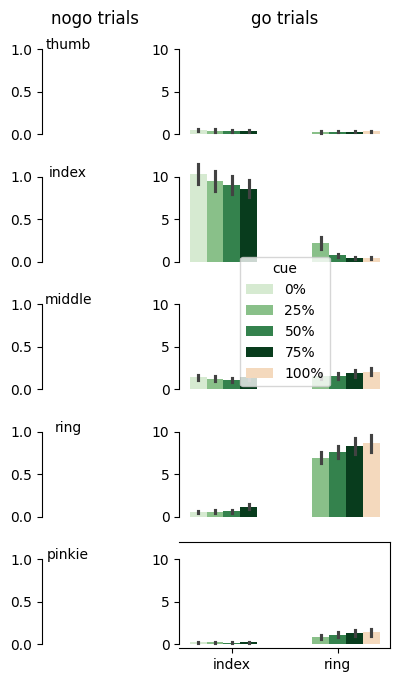

In [8]:
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

fig, axs = plt.subplots(5, 2, figsize=(4.5, 8), gridspec_kw={'width_ratios': [1, 2]})

# Build the correct palette to match Seaborn's internal order
cue_labels = gl.cues  # e.g. ['0%', '25%', '50%', '75%', '100%']
index_colors = [gl.colour_mapping[f'{cue},index'] for cue in cue_labels if f'{cue},index' in gl.colour_mapping]
ring_colors = [gl.colour_mapping[f'{cue},ring'] for cue in cue_labels if f'{cue},ring' in gl.colour_mapping]
palette = index_colors + ring_colors

# Plot go trials (right column)
for f, finger in enumerate(gl.channels['mov']):
    sns.barplot(
        x='stimFinger', y=finger + '1', ax=axs[f, 1], hue='cue',
        data=df[df['GoNogo'] == 'go'],
        order=['index', 'ring'], hue_order=gl.cues,
        palette=palette, errorbar='se', legend=(f == 2)
    )

    axs[f, 1].set_ylim([-.5, 12])
    axs[f, 1].set_xlabel('')
    axs[f, 1].set_ylabel('')
    axs[f, 1].spines[['left']].set_bounds(0, 10)

    if f < 4:
        axs[f, 1].set_xticks([])
        axs[f, 1].spines[['bottom', 'right', 'top']].set_visible(False)

    if f == 0:
        axs[f, 1].set_title('go trials')

# Plot nogo trials (left column)
for f, finger in enumerate(gl.channels['mov']):
    sns.barplot(
        x='stimFinger', y=finger + '0', ax=axs[f, 0], hue='cue',
        data=df[df['GoNogo'] == 'nogo'],
        order=['index', 'ring'], hue_order=gl.cues,
        palette=palette, errorbar='se', legend=False
    )

    axs[f, 0].set_ylim([-.05, 1.2])
    axs[f, 0].set_xlabel('')
    axs[f, 0].set_ylabel('')
    axs[f, 0].text(0, 1, finger, ha='center')
    axs[f, 0].spines[['left']].set_bounds(0, 1)

    axs[f, 0].set_xticks([])
    axs[f, 0].spines[['bottom', 'right', 'top']].set_visible(False)

    if f == 0:
        axs[f, 0].set_title('nogo trials')

save_figure_incremental(fig, 'force_response_binned')

In [9]:
# Retrieve emg data
channels = ['thumb_flex',
        'index_flex',
        'middle_flex',
        'ring_flex',
        'pinkie_flex',
        'thumb_ext',
        'index_ext',
        'middle_ext',
        'ring_ext',
        'pinkie_ext',
        'fdi']

participant_ids = ['subj100',
                   'subj101',
                   'subj102',
                   'subj103',
                   'subj104',
                   'subj105',
                   'subj106',
                   'subj107',
                   'subj108',
                   'subj109',
                   'subj110']


experiment = 'smp0'
path = os.path.join(gl.baseDir, experiment)
participants = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')

cue_code = [93, 12, 44, 21, 39]
stimFinger_code = [91999, 99919]

latency = pd.read_csv(os.path.join(gl.baseDir, 'smp0', 'clamped', 'smp0_clamped_latency.tsv'), sep='\t')
latency = latency['index'][0], latency['ring'][0]

Dict = {ch: [] for ch in channels}
for participant in participant_ids:

    sn = int(''.join([c for c in participant if c.isdigit()]))

    print(f'loading {participant}...')
    emg = np.load(os.path.join(path, 'emg',participant,  f'{experiment}_{sn}.npy'))
    dat = pd.read_csv(os.path.join(path, gl.behavDir, participant, f'{experiment}_{sn}.dat'), sep='\t')
    blocks = [int(b) for b in participants[participants['sn'] == sn].blocks_emg.iloc[0].split('.')]
    dat = dat[dat.BN.isin(blocks)]
    ch_p = participants[participants['sn'] == sn].channels_emg.iloc[0].split(',')

    for ch in Dict.keys():
        if ch in ch_p:
            idx = ch_p.index(ch)
            emg_av = np.zeros((len(cue_code), len(stimFinger_code), emg.shape[-1]))
            for sf, stimF in enumerate(stimFinger_code):
                for c, cue in enumerate(cue_code):
                    emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)

            Dict[ch].append(emg_av)


loading subj100...


/tmp/ipykernel_487567/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


loading subj101...


/tmp/ipykernel_487567/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


loading subj102...


...

/tmp/ipykernel_487567/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


loading subj109...


/tmp/ipykernel_487567/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


loading subj110...


/tmp/ipykernel_487567/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


/tmp/ipykernel_487567/436429070.py:21: RuntimeWarning: Mean of empty slice
  y = np.nanmean(data[:, c, s], axis=0) + ch * .1
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


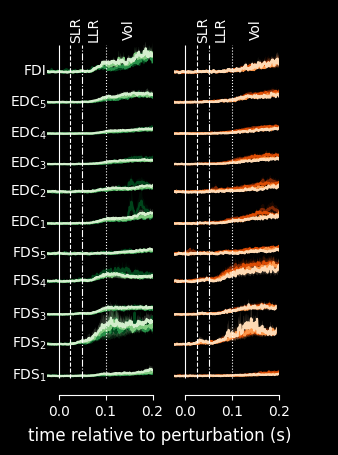

In [11]:
plt.style.use('dark_background')

# Time axis for each latency
tAx = [np.linspace(-1, 2, emg.shape[-1]) - l for l in latency]

# Set up plot
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(3, 5))

# Vertical lines and associated styles
line_xs = [0, .025, .05, .1]
line_styles = ['-', '--', '-.', ':']
line_labels = ['SLR', 'LLR', 'Vol']

for ch, channel in enumerate(Dict.keys()):
    for c, cue in enumerate(gl.cues[::-1]):
        for s, stimFinger in enumerate(gl.stimFinger):

            ax = axs[s]

            data = np.array(Dict[channel])
            y = np.nanmean(data[:, c, s], axis=0) + ch * .1
            yerr = np.nanstd(data[:, c, s], axis=0) / np.sqrt(len(participants))

            if ~np.isnan(y).any():
                ax.plot(tAx[s], y, color=gl.colour_mapping[f'{cue},{stimFinger}'])
                ax.fill_between(tAx[s], y- yerr, y + yerr,
                                color=gl.colour_mapping[f'{cue},{stimFinger}'], lw=0, alpha=.2)

            if (s == 0) & (c == 1):
                label = (f'FDS$_{{{ch+1}}}$' if ch < 5 else
                         f'EDC$_{{{ch-4}}}$' if (ch >= 5) & (ch < 10) else
                         'FDI' if ch == 10 else '')
                ax.text(-.025, y[0], label, va='center', ha='right',)

# Draw vertical lines
for ax in axs:
    for x, style in zip(line_xs, line_styles):
        ax.vlines(x, ymin=0, ymax=1.1, linestyles=style, color='w', lw=.8)

    ax.set_xlim([-.025, .2])

#     ax.set_ylim([0, 1.15])
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    # Remove y-ticks and labels
    ax.set_yticks([])
    ax.set_yticklabels([])

    ax.spines['bottom'].set_bounds([0, .2])
    ax.set_xticks([0, .1, .2])
    # set_spines_and_ticks_width(ax, spine_width=1.5, spine_sides=('bottom',), tick_width=1.5, axes=('x',), which='both')

    # Place text labels between key vertical lines
    xlims = ax.get_xlim()
    text_positions = [
        (.025 + .05) / 2,          # "SLR"
        (.05 + .1) / 2,            # "LLR"
        (.1 + xlims[1]) / 2        # "Vol"
    ]
    for label, xpos in zip(line_labels, text_positions):
        ax.text(xpos, 1.15, label, ha='center', va='center',  rotation=90,)
#
# # Global labels and layout
fig.supxlabel('time relative to perturbation (s)')
# fig.suptitle('EMG response to finger perturbation')
#
make_yref(axs[1], reference_length=.1, pos='right', unit='mV')

plt.show()
